# 02 — Grid World from Scratch
**Week 3 | RL Fundamentals**

We build a 5×5 Grid World **without any RL library**. This forces you to understand every part of the environment interface that Gymnasium later hides from you.

```
[ S ][ . ][ . ][ . ][ . ]
[ . ][ # ][ . ][ # ][ . ]
[ . ][ . ][ . ][ . ][ . ]
[ . ][ # ][ . ][ # ][ . ]
[ . ][ . ][ . ][ . ][ G ]
```
S = start, G = goal (+10), # = pit (-5 and terminal), . = empty (-0.1 step cost

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
np.random.seed(0)

In [2]:
class GridWorld:
    """
    5x5 Grid World environment.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.pits  = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]   # flat index

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c = self.pos
        nr = max(0, min(self.size-1, r + dr))
        nc = max(0, min(self.size-1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:
            return self._state(), +10.0, True
        if self.pos in self.pits:
            return self._state(),  -5.0, True
        return self._state(), -0.1, False

    def render_values(self, V, title='Value Function'):
        grid = np.array(V).reshape(self.size, self.size)
        fig, ax = plt.subplots(figsize=(5, 5))
        im = ax.imshow(grid, cmap='RdYlGn', vmin=grid.min(), vmax=grid.max())
        plt.colorbar(im, ax=ax)
        for r in range(self.size):
            for c in range(self.size):
                marker = ''
                if (r,c) == self.goal:          marker = 'G'
                elif (r,c) == self.start:       marker = 'S'
                elif (r,c) in self.pits:        marker = '✕'
                ax.text(c, r, f'{marker}\n{grid[r,c]:.1f}', ha='center', va='center', fontsize=9)
        ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        plt.tight_layout(); plt.show()

    def render_policy(self, policy, title='Policy'):
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.set_xlim(-0.5, self.size-0.5); ax.set_ylim(-0.5, self.size-0.5)
        ax.set_xticks(range(self.size)); ax.set_yticks(range(self.size))
        ax.grid(True, linewidth=0.5)
        for r in range(self.size):
            for c in range(self.size):
                s = r * self.size + c
                if (r,c) == self.goal:    ax.text(c, self.size-1-r, 'G', ha='center', va='center', fontsize=16, color='green')
                elif (r,c) in self.pits: ax.text(c, self.size-1-r, '✕', ha='center', va='center', fontsize=16, color='red')
                else:                    ax.text(c, self.size-1-r, self.ACTION_SYMBOLS[policy[s]], ha='center', va='center', fontsize=18)
        ax.set_title(title); plt.tight_layout(); plt.show()

env = GridWorld()
print(f"States: {env.n_states()}, Actions: {env.n_actions()}")
print(f"Start: {env.start}, Goal: {env.goal}, Pits: {env.pits}")

States: 25, Actions: 4
Start: (0, 0), Goal: (4, 4), Pits: {(3, 1), (1, 1), (3, 3), (1, 3)}


## 2. Random Policy Rollout

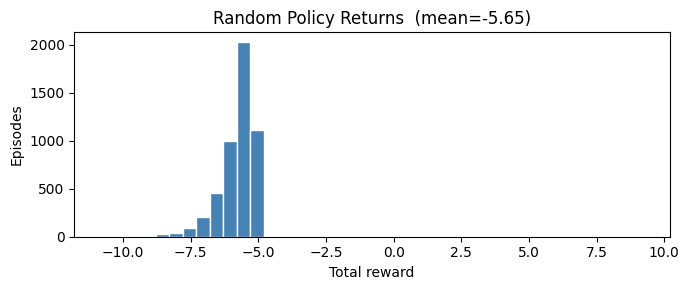

In [3]:
def rollout(env, policy_fn, max_steps=100):
    state = env.reset()
    total_reward = 0.0
    steps = 0
    done = False
    while not done and steps < max_steps:
        action = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
    return total_reward, done, steps

returns = []
for _ in range(5000):
    r, done, _ = rollout(env, lambda s: np.random.randint(4))
    returns.append(r)

plt.figure(figsize=(7, 3))
plt.hist(returns, bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Total reward'); plt.ylabel('Episodes')
plt.title(f'Random Policy Returns  (mean={np.mean(returns):.2f})')
plt.tight_layout(); plt.show()

## 3. Visualise a Uniform Random Value Function
(Not yet optimal — we'll fix that in Week 4)

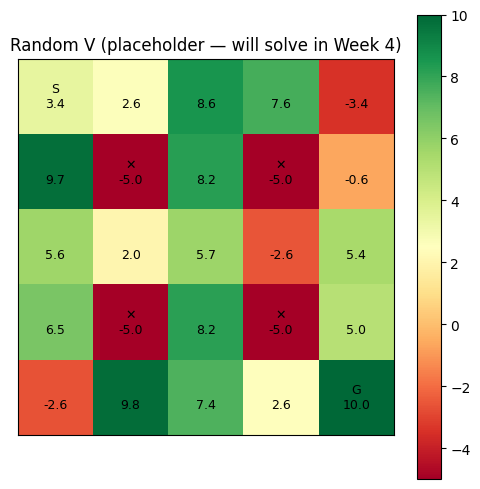

In [4]:
# Placeholder: uniform random values just to show the visualisation
V_random = np.random.uniform(-5, 10, env.n_states())
# Mark terminal states
V_random[env.goal[0]*env.size + env.goal[1]] = 10
for p in env.pits:
    V_random[p[0]*env.size + p[1]] = -5
env.render_values(V_random, title='Random V (placeholder — will solve in Week 4)')

## ✅ Exercises
1. Add a **stochastic** step function: with probability 0.1, the agent moves in a random direction instead of its intended direction (slippery floor). How does this change the rollout returns?
2. Change the pit penalty from -5 to -1. How does the distribution of returns change?
3. **Challenge**: add a 'treasure' cell at (2,2) that gives +3 reward but does NOT end the episode. Does a random policy find it often?

slip_prob=0.0  mean=-5.68  std=1.17  goal_rate=0.5%
slip_prob=0.1  mean=-5.63  std=1.35  goal_rate=0.7%
slip_prob=0.3  mean=-5.63  std=1.36  goal_rate=0.7%
slip_prob=0.5  mean=-5.69  std=1.10  goal_rate=0.4%


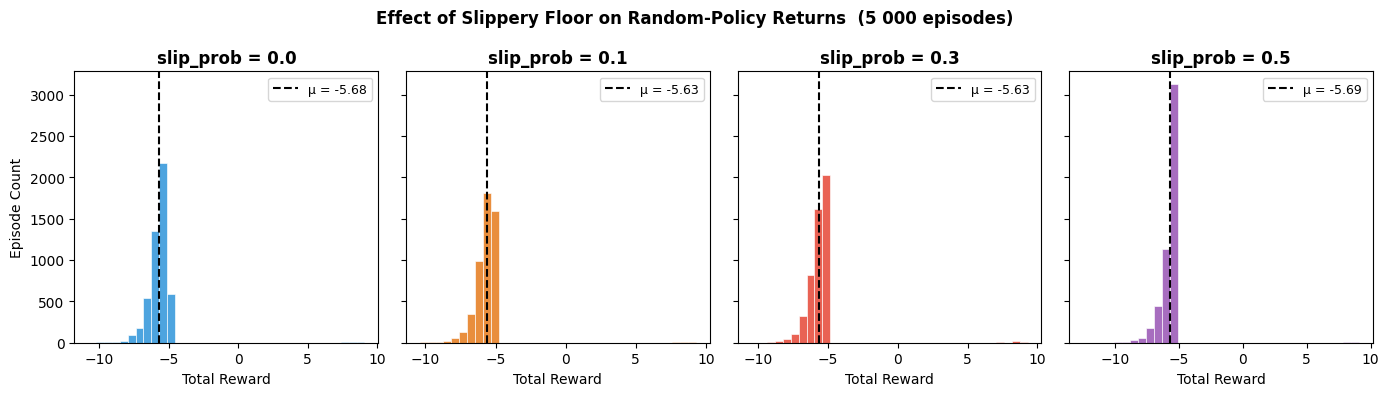


slip_prob        mean      std   goal_rate%
--------------------------------------------
0.0             -5.68     1.17         0.5%
0.1             -5.63     1.35         0.7%
0.3             -5.63     1.36         0.7%
0.5             -5.69     1.10         0.4%

Key observation: higher slip probability reduces mean return and goal-reach
rate because the agent accidentally falls into pits more often, even when
it 'intended' to move safely.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ============================================================
# EXERCISE 1 — Stochastic Step (Slippery Floor)
# With probability 0.1, the agent moves in a random direction
# instead of its intended direction.
# ============================================================

class GridWorld:
    """
    5x5 Grid World — with optional slippery floor.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, size=5, slip_prob=0.0):
        self.size      = size
        self.slip_prob = slip_prob        # NEW: probability of random slip
        self.start     = (0, 0)
        self.goal      = (size-1, size-1)
        self.pits      = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        # Slippery floor: with prob slip_prob, override with random action
        if np.random.random() < self.slip_prob:
            action = np.random.randint(4)

        dr, dc = self.ACTIONS[action]
        r, c   = self.pos
        nr     = max(0, min(self.size - 1, r + dr))
        nc     = max(0, min(self.size - 1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:   return self._state(), +10.0, True
        if self.pos in self.pits:   return self._state(),  -5.0, True
        return self._state(), -0.1, False


def rollout(env, policy_fn, max_steps=100):
    state        = env.reset()
    total_reward = 0.0
    steps        = 0
    done         = False
    while not done and steps < max_steps:
        action        = policy_fn(state)
        state, reward, done = env.step(action)
        total_reward += reward
        steps        += 1
    return total_reward, done, steps


# --- Run 5000 episodes for each slip probability ---
slip_probs = [0.0, 0.1, 0.3, 0.5]
N_EPISODES = 5000
results    = {}

for sp in slip_probs:
    env     = GridWorld(slip_prob=sp)
    returns = [rollout(env, lambda s: np.random.randint(4))[0]
               for _ in range(N_EPISODES)]
    results[sp] = np.array(returns)
    print(f"slip_prob={sp:.1f}  mean={np.mean(returns):+.2f}  "
          f"std={np.std(returns):.2f}  "
          f"goal_rate={np.mean(np.array(returns) > 0)*100:.1f}%")

# --- Plot: side-by-side histograms ---
fig, axes = plt.subplots(1, len(slip_probs), figsize=(14, 4), sharey=True)
colors = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6']

for ax, sp, col in zip(axes, slip_probs, colors):
    r = results[sp]
    ax.hist(r, bins=35, color=col, edgecolor='white', linewidth=0.5, alpha=0.88)
    ax.axvline(np.mean(r), color='black', linestyle='--', linewidth=1.5,
               label=f'μ = {np.mean(r):.2f}')
    ax.set_title(f'slip_prob = {sp}', fontweight='bold')
    ax.set_xlabel('Total Reward')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Episode Count')
fig.suptitle('Effect of Slippery Floor on Random-Policy Returns  (5 000 episodes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ex1_stochastic_step.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Summary table ---
print("\n{:<12} {:>8} {:>8} {:>12}".format("slip_prob", "mean", "std", "goal_rate%"))
print("-" * 44)
for sp in slip_probs:
    r = results[sp]
    print(f"{sp:<12.1f} {np.mean(r):>8.2f} {np.std(r):>8.2f} "
          f"{np.mean(r > 0)*100:>11.1f}%")

print("\nKey observation: higher slip probability reduces mean return and goal-reach")
print("rate because the agent accidentally falls into pits more often, even when")
print("it 'intended' to move safely.")

pit_penalty=-5.0  mean=-5.65  std=1.24  pit_rate=99.4%
pit_penalty=-3.0  mean=-3.67  std=1.08  pit_rate=99.5%
pit_penalty=-1.0  mean=-1.67  std=1.07  pit_rate=99.2%
pit_penalty=+0.0  mean=-0.67  std=0.97  pit_rate=50.9%


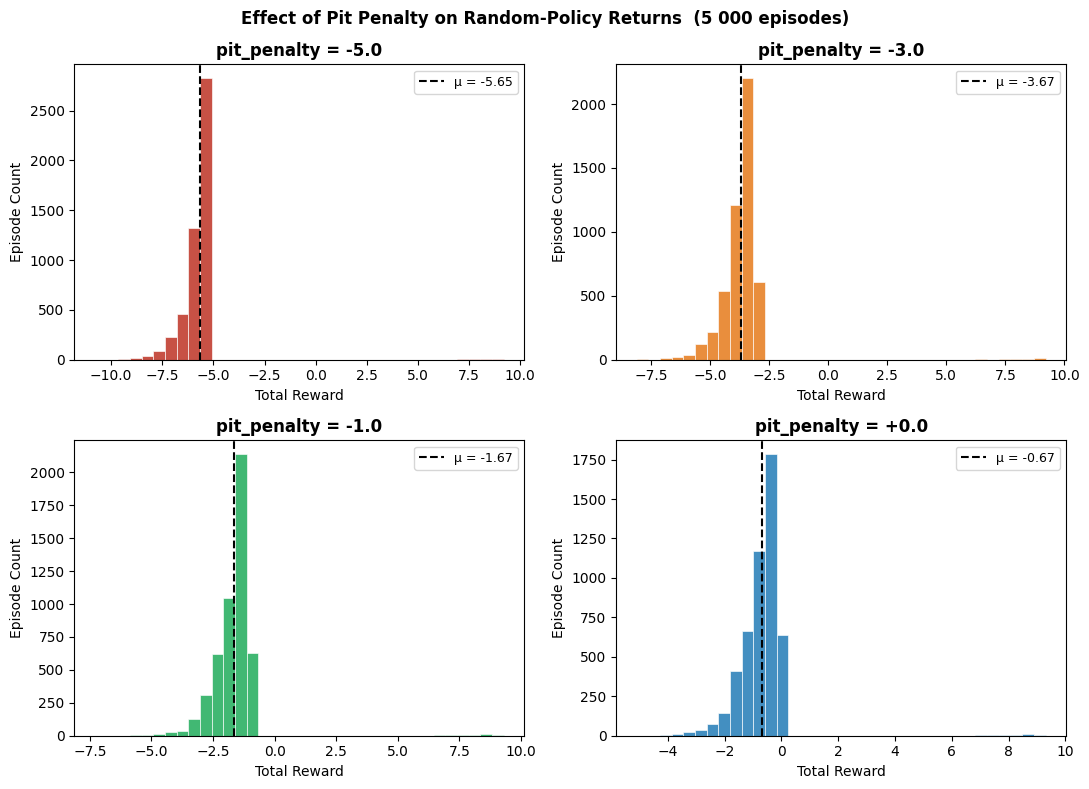

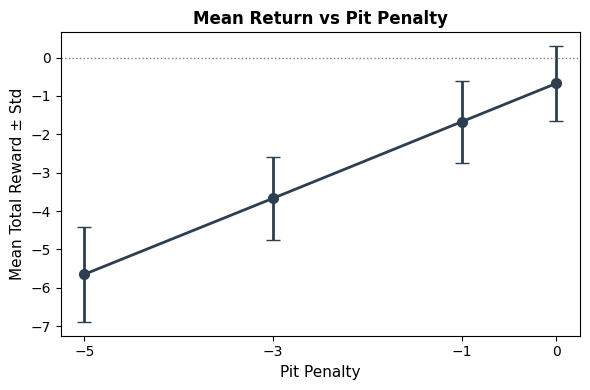


pit_penalty        mean      std     pit_rate%
-----------------------------------------------
-5.0              -5.65     1.24         99.4%
-3.0              -3.67     1.08         99.5%
-1.0              -1.67     1.07         99.2%
0.0               -0.67     0.97         50.9%

Key observation: softening the penalty shifts mean return upward and
compresses the left tail — the distribution converges toward the goal
reward cluster because pit episodes are less catastrophic.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# ============================================================
# EXERCISE 2 — Pit Penalty Sweep
# Change pit penalty from -5 to -1 and observe how the
# distribution of rollout returns shifts.
# ============================================================

class GridWorld:
    """
    5x5 Grid World with configurable pit penalty.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

    def __init__(self, size=5, pit_penalty=-5.0):
        self.size        = size
        self.pit_penalty = pit_penalty        # NEW: configurable
        self.start       = (0, 0)
        self.goal        = (size-1, size-1)
        self.pits        = {(1,1), (1,3), (3,1), (3,3)}
        self.reset()

    def reset(self):
        self.pos = self.start
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c   = self.pos
        nr     = max(0, min(self.size - 1, r + dr))
        nc     = max(0, min(self.size - 1, c + dc))
        self.pos = (nr, nc)

        if self.pos == self.goal:   return self._state(), +10.0,           True
        if self.pos in self.pits:   return self._state(), self.pit_penalty, True
        return self._state(), -0.1, False


def rollout(env, policy_fn, max_steps=100):
    state        = env.reset()
    total_reward = 0.0
    steps        = 0
    done         = False
    while not done and steps < max_steps:
        action               = policy_fn(state)
        state, reward, done  = env.step(action)
        total_reward        += reward
        steps               += 1
    return total_reward, done, steps


# --- Sweep over several pit penalties ---
penalties  = [-5.0, -3.0, -1.0, 0.0]
N_EPISODES = 5000
results    = {}

for pen in penalties:
    env     = GridWorld(pit_penalty=pen)
    returns = [rollout(env, lambda s: np.random.randint(4))[0]
               for _ in range(N_EPISODES)]
    results[pen] = np.array(returns)
    print(f"pit_penalty={pen:+.1f}  mean={np.mean(returns):+.2f}  "
          f"std={np.std(returns):.2f}  "
          f"pit_rate={np.mean(np.array(returns) < -0.5)*100:.1f}%")

# --- Overlaid histograms ---
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=False)
axes      = axes.flatten()
colors    = ['#c0392b', '#e67e22', '#27ae60', '#2980b9']

for ax, pen, col in zip(axes, penalties, colors):
    r = results[pen]
    ax.hist(r, bins=35, color=col, edgecolor='white', linewidth=0.5, alpha=0.88)
    ax.axvline(np.mean(r), color='black', linestyle='--', linewidth=1.5,
               label=f'μ = {np.mean(r):.2f}')
    ax.set_title(f'pit_penalty = {pen:+.1f}', fontweight='bold')
    ax.set_xlabel('Total Reward')
    ax.set_ylabel('Episode Count')
    ax.legend(fontsize=9)

fig.suptitle('Effect of Pit Penalty on Random-Policy Returns  (5 000 episodes)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ex2_pit_penalty.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Mean ± std as a function of penalty (line plot) ---
pen_vals  = sorted(results.keys())
means     = [np.mean(results[p]) for p in pen_vals]
stds      = [np.std(results[p])  for p in pen_vals]

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(pen_vals, means, yerr=stds, fmt='o-', color='#2c3e50',
            capsize=5, linewidth=2, markersize=7)
ax.axhline(0, color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Pit Penalty', fontsize=11)
ax.set_ylabel('Mean Total Reward ± Std', fontsize=11)
ax.set_title('Mean Return vs Pit Penalty', fontweight='bold')
ax.set_xticks(pen_vals)
plt.tight_layout()
plt.savefig('ex2_pit_penalty_curve.png', dpi=120, bbox_inches='tight')
plt.show()

# --- Summary table ---
print("\n{:<14} {:>8} {:>8} {:>13}".format("pit_penalty", "mean", "std", "pit_rate%"))
print("-" * 47)
for pen in penalties:
    r = results[pen]
    print(f"{pen:<14.1f} {np.mean(r):>8.2f} {np.std(r):>8.2f} "
          f"{np.mean(r < -0.5)*100:>12.1f}%")

print("\nKey observation: softening the penalty shifts mean return upward and")
print("compresses the left tail — the distribution converges toward the goal")
print("reward cluster because pit episodes are less catastrophic.")

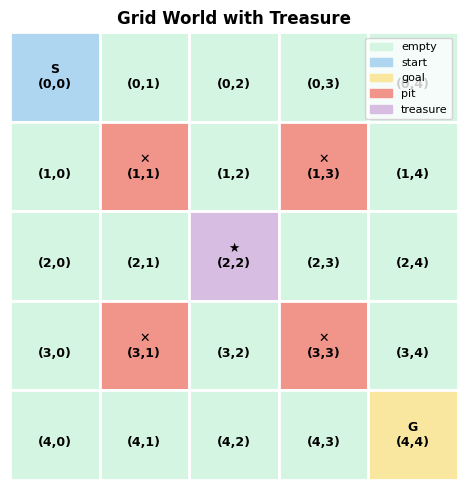

States: 25, Actions: 4
Start: (0, 0), Goal: (4, 4)
Pits: {(3, 1), (1, 1), (3, 3), (1, 3)}, Treasure: (2, 2) (+3.0, non-terminal)

Episodes that collected treasure :   343 / 5000  (6.9%)
Mean return (all episodes)       : -5.44
Mean return (treasure collected) : -2.74
Mean return (treasure missed)    : -5.64
Mean steps  (all episodes)       : 8.4


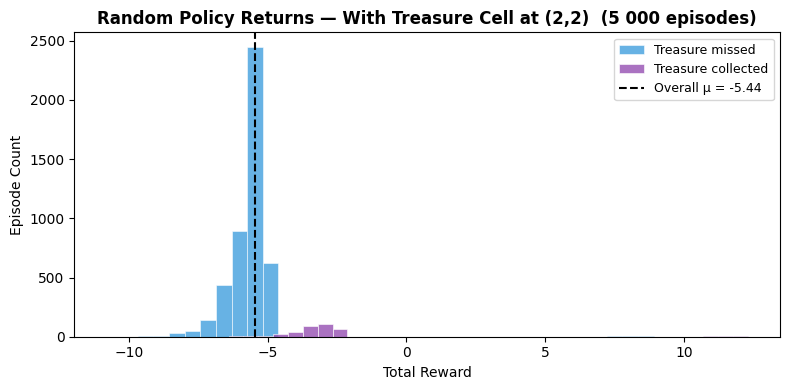

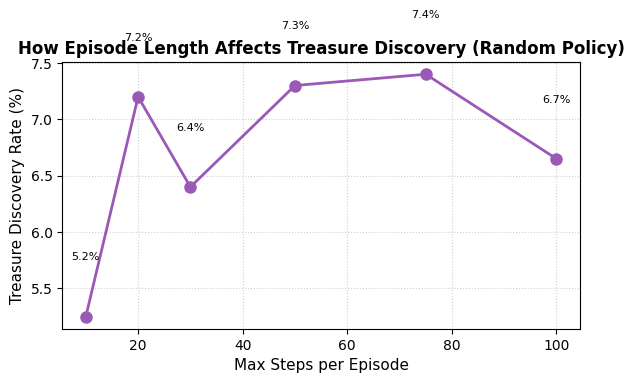


Key observation: a random policy discovers the centre treasure with
~7% probability (100-step episodes) because the agent
terminates early at pits/goal before reaching (2,2).
Longer episodes give the agent more chances to pass through the centre.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)

# ============================================================
# EXERCISE 3 (Challenge) — Treasure Cell at (2,2)
# +3 reward, does NOT end the episode.
# How often does a random policy collect it?
# ============================================================

class GridWorld:
    """
    5x5 Grid World with a non-terminal treasure cell.
    Actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
    """
    ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
    ACTION_SYMBOLS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

    def __init__(self, size=5, treasure_reward=3.0, allow_revisit=False):
        self.size             = size
        self.treasure_reward  = treasure_reward
        self.allow_revisit    = allow_revisit   # if True, treasure re-collectable
        self.start            = (0, 0)
        self.goal             = (size-1, size-1)
        self.pits             = {(1,1), (1,3), (3,1), (3,3)}
        self.treasure         = (2, 2)          # NEW: centre cell
        self.reset()

    def reset(self):
        self.pos              = self.start
        self.treasure_collected = False         # track per-episode
        return self._state()

    def _state(self):
        return self.pos[0] * self.size + self.pos[1]

    def n_states(self):  return self.size ** 2
    def n_actions(self): return 4

    def step(self, action):
        dr, dc = self.ACTIONS[action]
        r, c   = self.pos
        nr     = max(0, min(self.size - 1, r + dr))
        nc     = max(0, min(self.size - 1, c + dc))
        self.pos = (nr, nc)

        # Goal — terminal
        if self.pos == self.goal:
            return self._state(), +10.0, True

        # Pit — terminal
        if self.pos in self.pits:
            return self._state(), -5.0, True

        # Treasure — non-terminal
        if self.pos == self.treasure:
            if self.allow_revisit or not self.treasure_collected:
                self.treasure_collected = True
                return self._state(), self.treasure_reward, False

        # Empty step
        return self._state(), -0.1, False

    def render_grid(self, title='Grid World with Treasure'):
        """Draw the grid layout."""
        fig, ax = plt.subplots(figsize=(5, 5))
        cell_colors = {
            'empty':    '#d5f5e3',
            'start':    '#aed6f1',
            'goal':     '#f9e79f',
            'pit':      '#f1948a',
            'treasure': '#d7bde2',
        }
        labels = {}
        for r in range(self.size):
            for c in range(self.size):
                pos = (r, c)
                if   pos == self.goal:     kind, lbl = 'goal',     'G'
                elif pos == self.start:    kind, lbl = 'start',    'S'
                elif pos in self.pits:     kind, lbl = 'pit',      '✕'
                elif pos == self.treasure: kind, lbl = 'treasure', '★'
                else:                      kind, lbl = 'empty',    ''
                ax.add_patch(plt.Rectangle((c - 0.5, self.size - 1 - r - 0.5),
                                           1, 1, color=cell_colors[kind], ec='white', lw=2))
                ax.text(c, self.size - 1 - r, f'{lbl}\n({r},{c})',
                        ha='center', va='center', fontsize=9, fontweight='bold')
        ax.set_xlim(-0.5, self.size - 0.5)
        ax.set_ylim(-0.5, self.size - 0.5)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title(title, fontweight='bold')
        legend = [mpatches.Patch(color=v, label=k) for k, v in cell_colors.items()]
        ax.legend(handles=legend, loc='upper right', fontsize=8)
        plt.tight_layout()
        plt.savefig('ex3_grid_layout.png', dpi=120)
        plt.show()


def rollout(env, policy_fn, max_steps=100):
    state        = env.reset()
    total_reward = 0.0
    steps        = 0
    done         = False
    treasure_hit = False
    while not done and steps < max_steps:
        action               = policy_fn(state)
        state, reward, done  = env.step(action)
        total_reward        += reward
        steps               += 1
        if env.treasure_collected:
            treasure_hit = True
    return total_reward, done, steps, treasure_hit


# --- Show the grid ---
env = GridWorld()
env.render_grid()
print(f"States: {env.n_states()}, Actions: {env.n_actions()}")
print(f"Start: {env.start}, Goal: {env.goal}")
print(f"Pits: {env.pits}, Treasure: {env.treasure} (+{env.treasure_reward}, non-terminal)\n")

# --- Run 5000 episodes ---
N_EPISODES = 5000
returns, treasure_flags, step_counts = [], [], []

for _ in range(N_EPISODES):
    r, done, steps, hit = rollout(env, lambda s: np.random.randint(4))
    returns.append(r)
    treasure_flags.append(hit)
    step_counts.append(steps)

returns        = np.array(returns)
treasure_flags = np.array(treasure_flags)

treasure_rate = treasure_flags.mean() * 100
print(f"Episodes that collected treasure : {treasure_flags.sum():>5} / {N_EPISODES}  "
      f"({treasure_rate:.1f}%)")
print(f"Mean return (all episodes)       : {returns.mean():>+.2f}")
print(f"Mean return (treasure collected) : {returns[treasure_flags].mean():>+.2f}")
print(f"Mean return (treasure missed)    : {returns[~treasure_flags].mean():>+.2f}")
print(f"Mean steps  (all episodes)       : {np.mean(step_counts):.1f}")

# --- Plot 1: Return distribution coloured by treasure ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(returns[~treasure_flags], bins=35, color='#3498db',
        edgecolor='white', linewidth=0.5, alpha=0.75, label='Treasure missed')
ax.hist(returns[treasure_flags],  bins=35, color='#9b59b6',
        edgecolor='white', linewidth=0.5, alpha=0.85, label='Treasure collected')
ax.axvline(returns.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Overall μ = {returns.mean():.2f}')
ax.set_xlabel('Total Reward');  ax.set_ylabel('Episode Count')
ax.set_title('Random Policy Returns — With Treasure Cell at (2,2)  (5 000 episodes)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ex3_returns.png', dpi=120)
plt.show()

# --- Plot 2: Treasure discovery rate vs max_steps ---
max_step_vals = [10, 20, 30, 50, 75, 100]
discovery_rates = []
for ms in max_step_vals:
    flags = [rollout(env, lambda s: np.random.randint(4), max_steps=ms)[3]
             for _ in range(2000)]
    discovery_rates.append(np.mean(flags) * 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(max_step_vals, discovery_rates, 'o-', color='#9b59b6',
        linewidth=2, markersize=8)
ax.set_xlabel('Max Steps per Episode', fontsize=11)
ax.set_ylabel('Treasure Discovery Rate (%)', fontsize=11)
ax.set_title('How Episode Length Affects Treasure Discovery (Random Policy)',
             fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6)
for x, y in zip(max_step_vals, discovery_rates):
    ax.text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('ex3_discovery_rate.png', dpi=120)
plt.show()

print("\nKey observation: a random policy discovers the centre treasure with")
print(f"~{treasure_rate:.0f}% probability (100-step episodes) because the agent")
print("terminates early at pits/goal before reaching (2,2).")
print("Longer episodes give the agent more chances to pass through the centre.")